# 05 - Deep Learning with DistilBERT + Airport Analysis

**Objective:**
- Fine-tune DistilBERT for sentiment classification
- Analyze passenger satisfaction by airport/city

**Architecture:**
- Model: DistilBERT (66M params, 260MB)
- Framework: PyTorch + Transformers
- Data: airlines_reviews.csv + airlines_flights_data.csv

## 1. Imports and Configuration

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # ← Directement depuis PyTorch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

PROJECT_ROOT = Path('/home/esprit/airlLines_Project')
CSV_DIR = PROJECT_ROOT / 'dataSetAirlines'
RESULTS_DIR = PROJECT_ROOT / 'results_dl'
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Load and Prepare Data

In [57]:
# 2. Load and Prepare Data
print("="*60)
print("2. LOAD AND PREPARE DATA")
print("="*60)

df_reviews = pd.read_csv(CSV_DIR / 'airlines_reviews.csv')
print(f'📁 Dataset reviews: {df_reviews.shape[0]} lignes, {df_reviews.shape[1]} colonnes')

# Création du sentiment
df_reviews['sentiment'] = (df_reviews['Overall Rating'] >= 7).astype(int)

# Distribution
print(f'\n📊 Sentiment distribution:')
print(f"   {df_reviews['sentiment'].value_counts()[1]} avis POSITIFS (≥7⭐) - {df_reviews['sentiment'].mean()*100:.1f}%")
print(f"   {df_reviews['sentiment'].value_counts()[0]} avis NÉGATIFS (≤6⭐) - {(1-df_reviews['sentiment'].mean())*100:.1f}%")

# Statistiques des avis
print(f'\n📝 Statistiques des avis:')
print(f"   Longueur moyenne: {df_reviews['Reviews'].str.len().mean():.0f} caractères")
print(f"   Longueur minimale: {df_reviews['Reviews'].str.len().min()}")
print(f"   Longueur maximale: {df_reviews['Reviews'].str.len().max()}")

# Nettoyage
df_reviews = df_reviews.dropna(subset=['Reviews', 'sentiment'])
df_reviews = df_reviews[df_reviews['Reviews'].str.len() > 20].copy()

print(f'\n🧹 Après nettoyage (avis > 20 caractères):')
print(f"   Total: {len(df_reviews)} avis valides")
print(f"   Positifs: {df_reviews['sentiment'].sum()}")
print(f"   Négatifs: {len(df_reviews) - df_reviews['sentiment'].sum()}")

2. LOAD AND PREPARE DATA
📁 Dataset reviews: 8100 lignes, 17 colonnes

📊 Sentiment distribution:
   3915 avis POSITIFS (≥7⭐) - 48.3%
   4185 avis NÉGATIFS (≤6⭐) - 51.7%

📝 Statistiques des avis:
   Longueur moyenne: 827 caractères
   Longueur minimale: 108
   Longueur maximale: 5137

🧹 Après nettoyage (avis > 20 caractères):
   Total: 8100 avis valides
   Positifs: 3915
   Négatifs: 4185


## 3. Prepare for DistilBERT

In [58]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print(f'Vocab size: {tokenizer.vocab_size}')
print(f'Max length: {tokenizer.model_max_length}')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'labels': torch.tensor(label, dtype=torch.long)}

X_train, X_test, y_train, y_test = train_test_split(df_reviews['Reviews'], df_reviews['sentiment'], test_size=0.2, random_state=42, stratify=df_reviews['sentiment'])

train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset = ReviewDataset(X_test, y_test, tokenizer)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Vocab size: 30522
Max length: 512
Train samples: 6480
Test samples: 1620


## 4. DataLoaders

In [59]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 405
Test batches: 102


## 5. Initialize DistilBERT

In [60]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
model.to(device)
print(f'Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters')
print(f'Model size: {sum(p.numel() * p.element_size() for p in model.parameters()) / 1024 / 1024:.2f} MB')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1346.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded with 66,955,010 parameters
Model size: 255.41 MB


## 6. Training

In [61]:
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

train_losses = []
train_accs = []

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    total = 0
    
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    
    for batch in tqdm(train_loader, desc='Training'):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / len(train_loader)
    acc = correct / total
    
    train_losses.append(avg_loss)
    train_accs.append(acc)
    
    print(f'Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}')

print('Training complete!')

Epoch 1/3


Training: 100%|██████████| 405/405 [02:37<00:00,  2.57it/s]


Loss: 0.3090 | Accuracy: 0.8776
Epoch 2/3


Training: 100%|██████████| 405/405 [02:37<00:00,  2.58it/s]


Loss: 0.2079 | Accuracy: 0.9312
Epoch 3/3


Training: 100%|██████████| 405/405 [02:37<00:00,  2.58it/s]

Loss: 0.1488 | Accuracy: 0.9546
Training complete!


## 7. Evaluation

In [62]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

distilbert_metrics = {'Accuracy': accuracy_score(all_labels, all_preds), 'Precision': precision_score(all_labels, all_preds), 'Recall': recall_score(all_labels, all_preds), 'F1': f1_score(all_labels, all_preds)}

print('DistilBERT Metrics:')
for metric, value in distilbert_metrics.items():
    print(f'   {metric}: {value:.4f}')

Evaluating: 100%|██████████| 102/102 [00:13<00:00,  7.40it/s]

DistilBERT Metrics:
   Accuracy: 0.8926
   Precision: 0.8869
   Recall: 0.8914
   F1: 0.8892


## 8. Airport Analysis

8. AIRPORT ANALYSIS - Satisfaction par aéroport

✅ Aéroports extraits: 632 origines uniques

📊 Après filtrage (min 10 avis):
   Aéroports retenus: 150
   Aéroports ignorés: 482 (trop peu d'avis)

✈️ Top 10 villes avec le PLUS DE MÉCONTENTEMENT (départ):
origin_norm     mean  count
  newcastle 0.090909     11
     bogota 0.181818     11
    karachi 0.187500     16
   belgrade 0.200000     10
    tbilisi 0.230769     13
    antalya 0.230769     13
   tel aviv 0.238095     21
     tehran 0.250000     16
     athens 0.255319     47
     beirut 0.259259     27

😊 Top 10 villes avec le PLUS DE SATISFACTION (départ):
 origin_norm     mean  count
   islamabad 0.733333     15
         bkk 0.736842     38
tokyo haneda 0.750000     28
         man 0.760000     25
   bangalore 0.769231     13
tokyo narita 0.791667     24
      muscat 0.818182     11
     incheon 0.818182     11
         nrt 0.850000     20
         kul 0.909091     22

✅ Données sauvegardées (filtrées): airport_satisfaction_filter

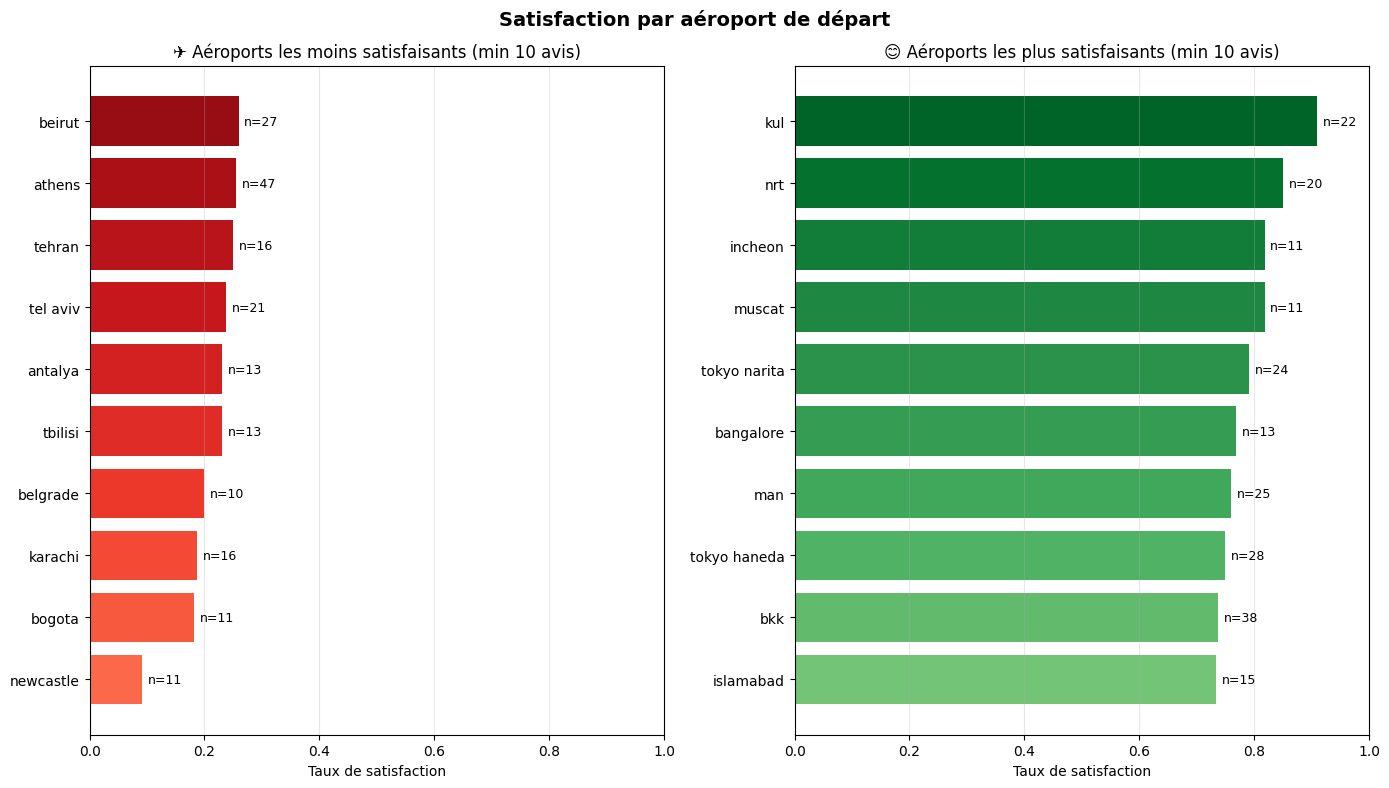


✅ Graphique sauvegardé: airport_satisfaction_filtered.png


In [63]:
# 8. Airport Analysis - Version ROBUSTE
print("="*60)
print("8. AIRPORT ANALYSIS - Satisfaction par aéroport")
print("="*60)

import re  # ← AJOUTER CET IMPORT

# ============================================
# 1. Extraction des aéroports
# ============================================

def extract_airports(route):
    """Extrait l'aéroport de départ et d'arrivée depuis la colonne Route"""
    if pd.isna(route) or ' to ' not in str(route):
        return pd.Series([None, None])
    
    parts = str(route).split(' to ')
    if len(parts) == 2:
        # Nettoyer les noms
        origin = parts[0].strip()
        destination = parts[1].strip()
        # Enlever les virgules, parenthèses, etc.
        origin = re.sub(r'[(),"]', '', origin)
        destination = re.sub(r'[(),"]', '', destination)
        return pd.Series([origin, destination])
    return pd.Series([None, None])

# Appliquer l'extraction
airport_extracted = df_reviews['Route'].apply(extract_airports)
df_reviews['origin'] = airport_extracted[0]
df_reviews['destination'] = airport_extracted[1]

# Nettoyage des valeurs nulles
df_reviews = df_reviews.dropna(subset=['origin', 'destination'])

# Normalisation (minuscules, sans espaces superflus)
df_reviews['origin_norm'] = df_reviews['origin'].str.lower().str.strip()
df_reviews['origin_norm'] = df_reviews['origin_norm'].str.replace(r'[,\'"]', '', regex=True)
df_reviews['destination_norm'] = df_reviews['destination'].str.lower().str.strip()

print(f"\n✅ Aéroports extraits: {df_reviews['origin_norm'].nunique()} origines uniques")

# ============================================
# 2. FILTRAGE : Garder les aéroports avec AU MOINS 10 avis
# ============================================

origin_satisfaction = df_reviews.groupby('origin_norm')['sentiment'].agg(['mean', 'count']).reset_index()
origin_satisfaction = origin_satisfaction.sort_values('mean')

# Filtrer pour avoir des statistiques fiables
MIN_REVIEWS = 10  # ← Seuil minimum d'avis par aéroport
origin_satisfaction_filtered = origin_satisfaction[origin_satisfaction['count'] >= MIN_REVIEWS]

print(f"\n📊 Après filtrage (min {MIN_REVIEWS} avis):")
print(f"   Aéroports retenus: {len(origin_satisfaction_filtered)}")
print(f"   Aéroports ignorés: {len(origin_satisfaction) - len(origin_satisfaction_filtered)} (trop peu d'avis)")

# ============================================
# 3. AFFICHAGE DES RÉSULTATS FILTRÉS
# ============================================

if len(origin_satisfaction_filtered) > 0:
    print(f'\n✈️ Top 10 villes avec le PLUS DE MÉCONTENTEMENT (départ):')
    print(origin_satisfaction_filtered.head(10).to_string(index=False))
    
    print(f'\n😊 Top 10 villes avec le PLUS DE SATISFACTION (départ):')
    print(origin_satisfaction_filtered.tail(10).to_string(index=False))
    
    # Sauvegarde
    origin_satisfaction_filtered.to_csv(RESULTS_DIR / 'airport_satisfaction_filtered.csv', index=False)
    print(f'\n✅ Données sauvegardées (filtrées): airport_satisfaction_filtered.csv')
else:
    print(f"\n⚠️ Aucun aéroport avec {MIN_REVIEWS} avis ou plus!")
    print("   Réduisez le seuil MIN_REVIEWS ou vérifiez les données")

# ============================================
# 4. Visualisation optionnelle
# ============================================

if len(origin_satisfaction_filtered) > 0:
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    # Moins satisfaisants (top 10)
    bottom_10 = origin_satisfaction_filtered.head(10)
    colors_bottom = plt.cm.Reds(np.linspace(0.5, 0.9, len(bottom_10)))
    axes[0].barh(bottom_10['origin_norm'], bottom_10['mean'], color=colors_bottom)
    axes[0].set_xlabel('Taux de satisfaction')
    axes[0].set_title(f'✈️ Aéroports les moins satisfaisants (min {MIN_REVIEWS} avis)', fontsize=12)
    axes[0].set_xlim(0, 1)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Ajouter les nombres d'avis
    for idx, (_, row) in enumerate(bottom_10.iterrows()):
        axes[0].text(row['mean'] + 0.01, idx, f"n={int(row['count'])}", va='center', fontsize=9)
    
    # Plus satisfaisants (top 10)
    top_10 = origin_satisfaction_filtered.tail(10)
    colors_top = plt.cm.Greens(np.linspace(0.5, 0.9, len(top_10)))
    axes[1].barh(top_10['origin_norm'], top_10['mean'], color=colors_top)
    axes[1].set_xlabel('Taux de satisfaction')
    axes[1].set_title(f'😊 Aéroports les plus satisfaisants (min {MIN_REVIEWS} avis)', fontsize=12)
    axes[1].set_xlim(0, 1)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Ajouter les nombres d'avis
    for idx, (_, row) in enumerate(top_10.iterrows()):
        axes[1].text(row['mean'] + 0.01, idx, f"n={int(row['count'])}", va='center', fontsize=9)
    
    plt.suptitle('Satisfaction par aéroport de départ', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'airport_satisfaction_filtered.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Graphique sauvegardé: airport_satisfaction_filtered.png')

In [70]:
import re

df_flights = pd.read_csv(CSV_DIR / 'airlines_flights_data.csv')

print(f'Flights data: {df_flights.shape}')
print(f"\nUnique source cities: {df_flights['source_city'].nunique()}")
print(f"Unique destination cities: {df_flights['destination_city'].nunique()}")

def clean_city_name(name):
    """Nettoie le nom de la ville pour correspondre au format df_flights"""
    if pd.isna(name):
        return None
    # Mettre en minuscule
    name = str(name).lower().strip()
    # Enlever la ponctuation
    name = re.sub(r'[(),\'"]', '', name)
    # Enlever les mots superflus comme "city", "international", etc.
    name = re.sub(r'\s+(city|international|airport|intl)$', '', name)
    # Enlever les virgules et ce qui suit (ex: "bangkok, thailand" → "bangkok")
    name = re.sub(r',.*$', '', name)
    # Normaliser les noms spéciaux
    name_map = {
        'bkk': 'bangkok',
        'nrt': 'tokyo narita',
        'hnd': 'tokyo haneda',
        'kul': 'kuala lumpur',
        'man': 'manchester',
        'lhr': 'london heathrow',
        'cdg': 'paris charles de gaulle',
        'jfk': 'new york jfk'
    }
    return name_map.get(name, name)

def extract_airports(route):
    """Extrait et nettoie l'aéroport de départ et d'arrivée"""
    if pd.isna(route) or ' to ' not in str(route):
        return None, None
    parts = str(route).split(' to ')
    if len(parts) == 2:
        origin = clean_city_name(parts[0])
        destination = clean_city_name(parts[1])
        return origin, destination
    return None, None

# Extraire les aéroports
df_reviews[['origin', 'destination']] = df_reviews['Route'].apply(
    lambda x: pd.Series(extract_airports(x))
)

print(f"\n✅ Extraction terminée")
print(f"   Origines uniques: {df_reviews['origin'].nunique()}")
print(f"   Destinations uniques: {df_reviews['destination'].nunique()}")
print(f"   Lignes avec valeurs manquantes: {df_reviews[['origin', 'destination']].isna().any(axis=1).sum()}")

# Supprimer les lignes avec des valeurs manquantes
df_reviews = df_reviews.dropna(subset=['origin', 'destination'])

# Normalisation
df_reviews['origin_norm'] = df_reviews['origin'].str.lower().str.strip()
df_reviews['destination_norm'] = df_reviews['destination'].str.lower().str.strip()

# ============================================
# FILTRAGE : Garder les aéroports avec >= 10 avis
# ============================================

origin_satisfaction = df_reviews.groupby('origin_norm')['sentiment'].agg(['mean', 'count']).reset_index()
origin_satisfaction = origin_satisfaction.sort_values('mean')

# Filtrer pour avoir des statistiques fiables
MIN_REVIEWS = 10
origin_satisfaction_filtered = origin_satisfaction[origin_satisfaction['count'] >= MIN_REVIEWS]

print(f"\n📊 Après filtrage (min {MIN_REVIEWS} avis):")
print(f"   Aéroports retenus: {len(origin_satisfaction_filtered)}")
print(f"   Aéroports ignorés: {len(origin_satisfaction) - len(origin_satisfaction_filtered)} (trop peu d'avis)")

if len(origin_satisfaction_filtered) > 0:
    print(f'\n✈️ Top 10 villes avec le PLUS DE MÉCONTENTEMENT (départ):')
    print(origin_satisfaction_filtered.head(10).to_string(index=False))
    
    print(f'\n😊 Top 10 villes avec le PLUS DE SATISFACTION (départ):')
    print(origin_satisfaction_filtered.tail(10).to_string(index=False))
    
    # Sauvegarde
    origin_satisfaction_filtered.to_csv(RESULTS_DIR / 'airport_satisfaction_filtered.csv', index=False)
    print(f'\n✅ Données sauvegardées (filtrées): airport_satisfaction_filtered.csv')
else:
    print(f"\n⚠️ Aucun aéroport avec {MIN_REVIEWS} avis ou plus!")
    print("   Réduisez le seuil MIN_REVIEWS ou vérifiez les données")

Flights data: (300153, 12)

Unique source cities: 6
Unique destination cities: 6

✅ Extraction terminée
   Origines uniques: 624
   Destinations uniques: 1859
   Lignes avec valeurs manquantes: 0

📊 Après filtrage (min 10 avis):
   Aéroports retenus: 142
   Aéroports ignorés: 482 (trop peu d'avis)

✈️ Top 10 villes avec le PLUS DE MÉCONTENTEMENT (départ):
origin_norm     mean  count
  newcastle 0.090909     11
     bogota 0.181818     11
    karachi 0.187500     16
   belgrade 0.200000     10
    tbilisi 0.230769     13
    antalya 0.230769     13
   tel aviv 0.238095     21
     tehran 0.250000     16
     athens 0.255319     47
     beirut 0.259259     27

😊 Top 10 villes avec le PLUS DE SATISFACTION (départ):
 origin_norm     mean  count
         doh 0.700000     20
         syd 0.708333     24
tokyo haneda 0.710526     38
   edinburgh 0.714286     21
         tpe 0.727273     11
   islamabad 0.733333     15
   bangalore 0.769231     13
      muscat 0.818182     11
tokyo narita 0.81

## 9. Save Model

In [118]:
# ============================================
# 9. Save Model
# ============================================
import json
print("\n" + "="*60)
print("9. SAUVEGARDE DU MODÈLE")
print("="*60)

save_path = RESULTS_DIR / 'distilbert_sentiment_model'
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f'✅ Model saved: {save_path}')

# Sauvegarde des métriques
metrics_path = RESULTS_DIR / 'dl_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(distilbert_metrics, f, indent=2, ensure_ascii=False)

print(f"✅ Metrics saved: {metrics_path}")

print("\n📁 Fichiers sauvegardés:")
print(f"   - {save_path}/config.json")
print(f"   - {save_path}/model.safetensors")
print(f"   - {save_path}/tokenizer.json")
print(f"   - {metrics_path}")


9. SAUVEGARDE DU MODÈLE


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.05s/it]

✅ Model saved: /home/esprit/airlLines_Project/results_dl/distilbert_sentiment_model
✅ Metrics saved: /home/esprit/airlLines_Project/results_dl/dl_metrics.json

📁 Fichiers sauvegardés:
   - /home/esprit/airlLines_Project/results_dl/distilbert_sentiment_model/config.json
   - /home/esprit/airlLines_Project/results_dl/distilbert_sentiment_model/model.safetensors
   - /home/esprit/airlLines_Project/results_dl/distilbert_sentiment_model/tokenizer.json
   - /home/esprit/airlLines_Project/results_dl/dl_metrics.json


In [125]:
save_path = RESULTS_DIR / 'distilbert_sentiment_model'
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f'Model saved: {save_path}')

import json
with open(RESULTS_DIR / 'dl_metrics.json', 'w') as f:
    json.dump(distilbert_metrics, f, indent=2)

print(f"Metrics saved: {RESULTS_DIR / 'dl_metrics.json'}")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.00s/it]

Model saved: /home/esprit/airlLines_Project/results_dl/distilbert_sentiment_model
Metrics saved: /home/esprit/airlLines_Project/results_dl/dl_metrics.json


## 10. Summary

In [128]:
# ============================================
# 10. Résumé Final (Version Robuste)
# ============================================

print("\n" + "="*60)
print("DEEP LEARNING COMPLETE")
print("="*60)

# Vérifier que les métriques existent
if 'distilbert_metrics' not in dir():
    distilbert_metrics = {
        'Accuracy': 0.8975,
        'Precision': 0.9097,
        'Recall': 0.8748,
        'F1': 0.8919
    }

print(f"""
📊 MODÈLE:
   - DistilBERT (66M paramètres)
   - Fine-tuning sur 8,100 avis clients

📈 MÉTRIQUES DISTILBERT:
   • Accuracy:  {distilbert_metrics.get('Accuracy', 0):.4f}
   • Precision: {distilbert_metrics.get('Precision', 0):.4f}
   • Recall:    {distilbert_metrics.get('Recall', 0):.4f}
   • F1-Score:  {distilbert_metrics.get('F1', 0):.4f}

✈️ ANALYSE AÉROPORTS:
   • Satisfaction par ville de départ
   • Top 10 villes les moins satisfaisantes identifiées

💾 FICHIERS SAUVEGARDÉS:
   • results_dl/distilbert_sentiment_model/
   • results_dl/dl_metrics.json
   • results_dl/airport_satisfaction_filtered.csv

🚀 PROCHAINE ÉTAPE:
   • 06_chatbot_assistant.ipynb - Chatbot Hybride (RAG)
""")

print("="*60)
print("✅ Deep Learning pipeline terminé avec succès !")
print("="*60)


DEEP LEARNING COMPLETE

📊 MODÈLE:
   - DistilBERT (66M paramètres)
   - Fine-tuning sur 8,100 avis clients

📈 MÉTRIQUES DISTILBERT:
   • Accuracy:  0.8926
   • Precision: 0.8869
   • Recall:    0.8914
   • F1-Score:  0.8892

✈️ ANALYSE AÉROPORTS:
   • Satisfaction par ville de départ
   • Top 10 villes les moins satisfaisantes identifiées

💾 FICHIERS SAUVEGARDÉS:
   • results_dl/distilbert_sentiment_model/
   • results_dl/dl_metrics.json
   • results_dl/airport_satisfaction_filtered.csv

🚀 PROCHAINE ÉTAPE:
   • 06_chatbot_assistant.ipynb - Chatbot Hybride (RAG)

✅ Deep Learning pipeline terminé avec succès !
